In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [59]:
df = pd.read_csv('../dataset/UniversalBank.csv')
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [60]:
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [61]:
loc_df = df.drop(["ID", "ZIP Code"], axis=1)
loc_df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [62]:
# Find the abnormal values
loc_experience_df = df[df["Experience"] < 0]
loc_experience_df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
89,90,25,-1,113,94303,4,2.30,3,0,0,0,0,0,1
226,227,24,-1,39,94085,2,1.70,2,0,0,0,0,0,0
315,316,24,-2,51,90630,3,0.30,3,0,0,0,0,1,0
451,452,28,-2,48,94132,2,1.75,3,89,0,0,0,1,0
524,525,24,-1,75,93014,4,0.20,1,0,0,0,0,1,0
536,537,25,-1,43,92173,3,2.40,2,176,0,0,0,1,0
540,541,25,-1,109,94010,4,2.30,3,314,0,0,0,1,0
576,577,25,-1,48,92870,3,0.30,3,0,0,0,0,0,1
583,584,24,-1,38,95045,2,1.70,2,0,0,0,0,1,0
597,598,24,-2,125,92835,2,7.20,1,0,0,1,0,0,1


### Plotting the correlations between features

<Axes: title={'center': 'Heatmap showing the Correlations between all features'}>

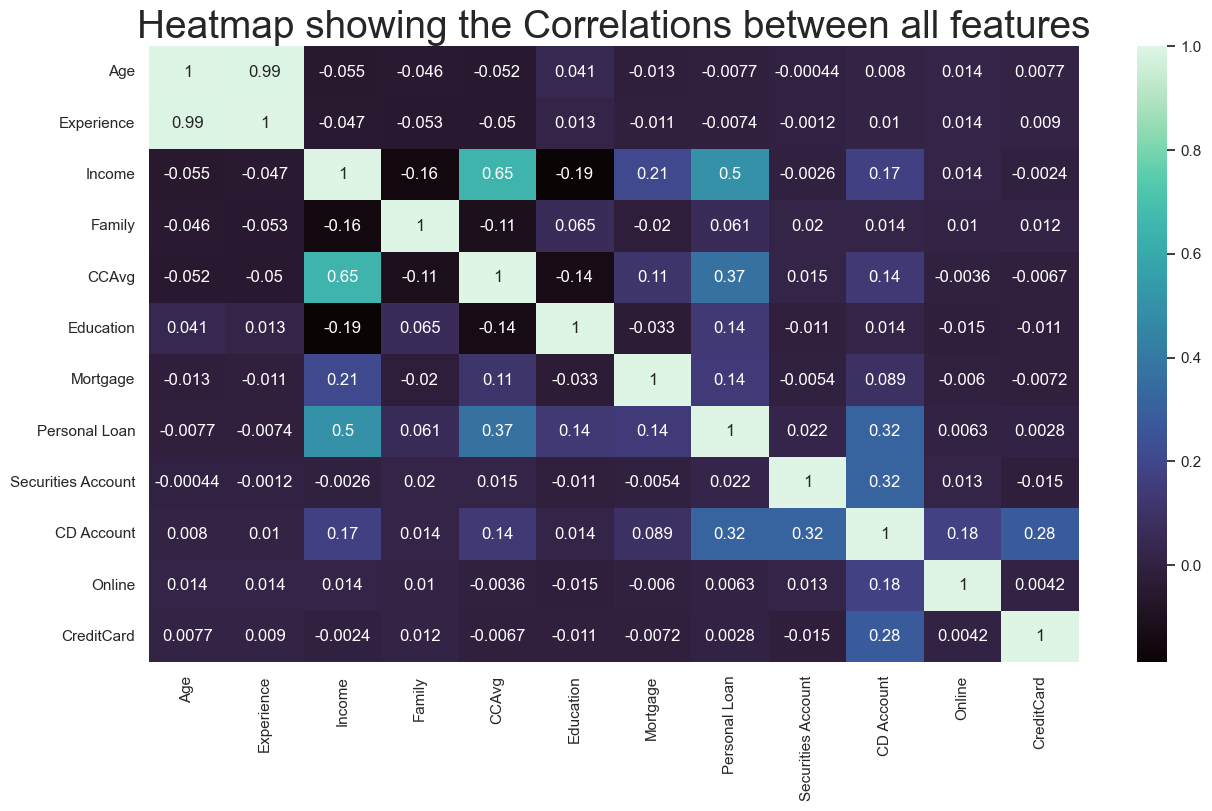

In [63]:
plt.figure(figsize=(15,8))
plt.title("Heatmap showing the Correlations between all features", fontsize = 28)
sns.heatmap(loc_df.corr(), annot=True, cmap='mako')

In [64]:
# Because the data in Experience have negaitve value (invalid).
# Base on Correlation between [Age] and [Experience] = 0.99
# Therefore, remove Experience
loc_df = loc_df.drop(["Experience"], axis=1)
loc_df

,Age,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,49,4,1.6,1,0,0,1,0,0,0
1,45,34,3,1.5,1,0,0,1,0,0,0
2,39,11,1,1.0,1,0,0,0,0,0,0
3,35,100,1,2.7,2,0,0,0,0,0,0
4,35,45,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,29,40,1,1.9,3,0,0,0,0,1,0
4996,30,15,4,0.4,1,85,0,0,0,1,0
4997,63,24,2,0.3,3,0,0,0,0,0,0
4998,65,49,3,0.5,2,0,0,0,0,1,0


### Descriptive Statistics

In [65]:
stats_cols = ['Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage']

stats = loc_df[stats_cols].describe()
print(stats)

               Age       Income       Family        CCAvg    Education  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean     45.338400    73.774200     2.396400     1.937938     1.881000   
std      11.463166    46.033729     1.147663     1.747659     0.839869   
min      23.000000     8.000000     1.000000     0.000000     1.000000   
25%      35.000000    39.000000     1.000000     0.700000     1.000000   
50%      45.000000    64.000000     2.000000     1.500000     2.000000   
75%      55.000000    98.000000     3.000000     2.500000     3.000000   
max      67.000000   224.000000     4.000000    10.000000     3.000000   

          Mortgage  
count  5000.000000  
mean     56.498800  
std     101.713802  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%     101.000000  
max     635.000000  


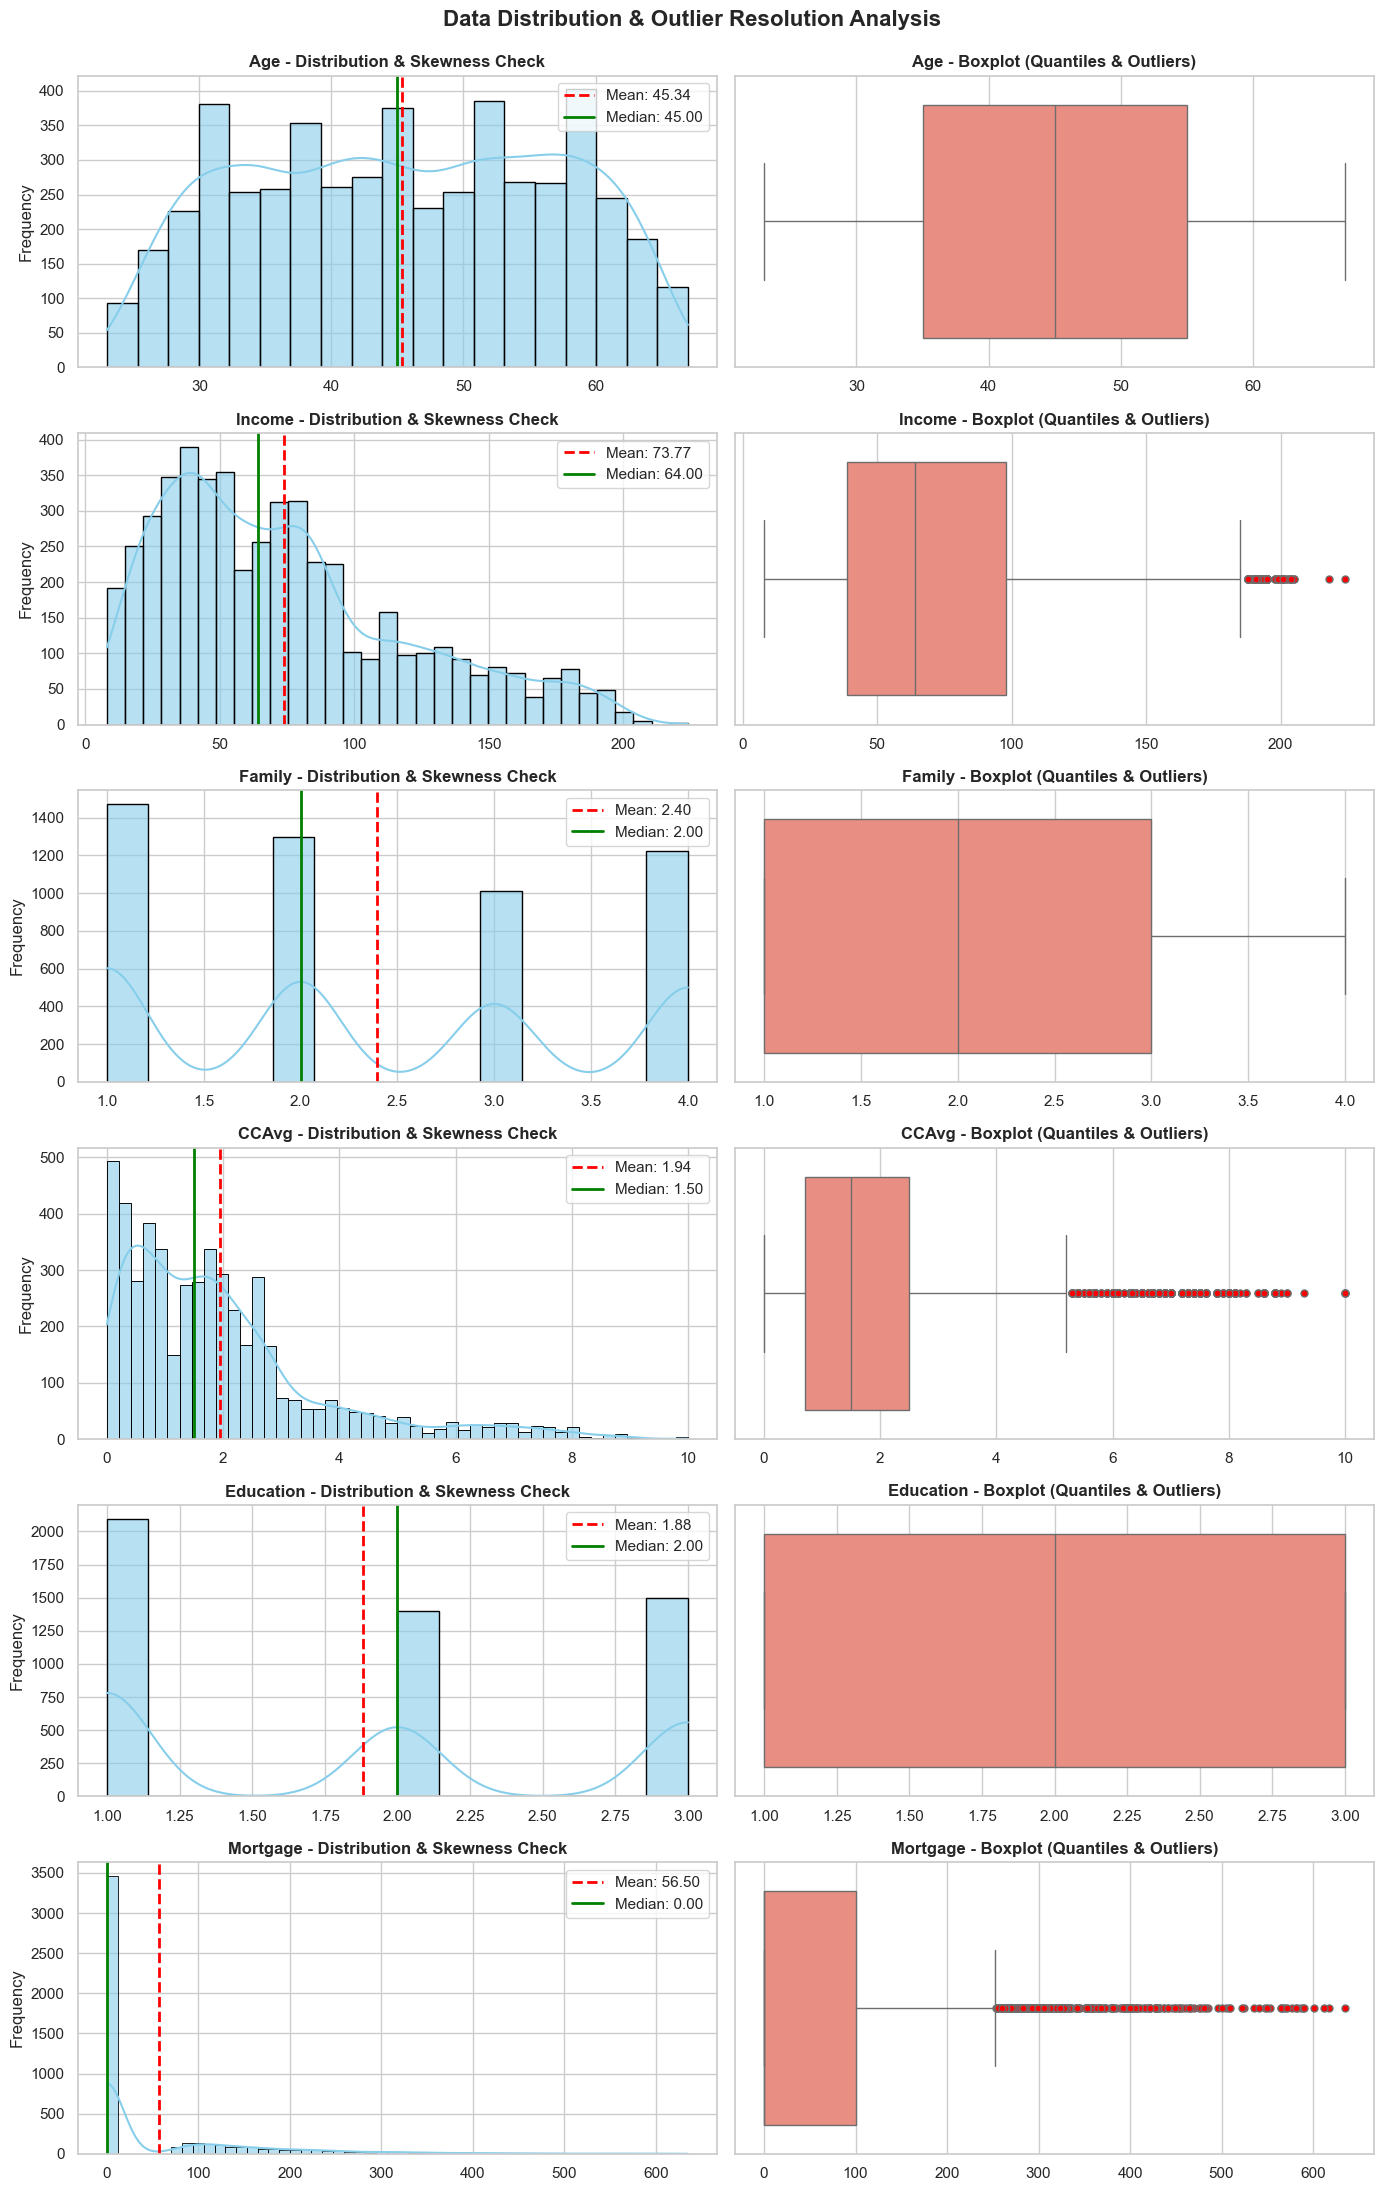

In [66]:
#Set overall plot styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(14,22))
fig.suptitle('Data Distribution & Outlier Resolution Analysis', fontsize=16, fontweight='bold', y=0.995)

for i, col in enumerate(stats_cols):
    mean_val = loc_df[col].mean()
    median_val = loc_df[col].median()
    
    # 1. Left Subplot: Histogram + Kernel Density Estimate (KDE)
    sns.histplot(loc_df[col], kde=True, ax=axes[i, 0], color='skyblue', edgecolor='black', alpha=0.6)
    axes[i, 0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i, 0].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[i, 0].set_title(f'{col} - Distribution & Skewness Check', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].legend(loc='upper right')
    
    # 2. Right Subplot: Boxplot for IQR & Outlier Visual Inspection
    sns.boxplot(x=loc_df[col], ax=axes[i, 1], color='salmon', flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5})
    axes[i, 1].set_title(f'{col} - Boxplot (Quantiles & Outliers)', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

### Check the Correlate between (Family, Education) and CreditCard

In [81]:
critical_values = {1: 3.841, 2: 5.991, 3: 7.815, 4: 9.488}

In [83]:
for col_name in ['Family', 'Education']:
    obs = pd.crosstab(loc_df[col_name], loc_df['CreditCard']).values
    r_obs = obs.sum(axis=0, keepdims=True)
    c_obs = obs.sum(axis=1, keepdims=True)

    #Determine the Degree of Freedom
    df_val = (obs.shape[0] - 1) * (obs.shape[1] - 1)
    critical_val = critical_values[df_val]

    q = (c_obs @ r_obs) / loc_df.shape[0]
    chi_square = np.sum(((obs - q) ** 2) / q)

    print(f"\n--- Evaluated: {col_name} ---")
    print(f"Chi-Square Stat: {chi_square:.4f} | Critical Value (df={df_val}): {critical_val}")
    
    if chi_square > critical_val:
        print(f"=> Reject H0: {col_name} HAS a significant relation with CreditCard -> [KEEP]")
    else:
        print(f"=> Fail to reject H0: {col_name} is INDEPENDENT of CreditCard -> [DROP]")


--- Evaluated: Family ---
Chi-Square Stat: 3.8389 | Critical Value (df=3): 7.815
=> Fail to reject H0: Family is INDEPENDENT of CreditCard -> [DROP]

--- Evaluated: Education ---
Chi-Square Stat: 1.2411 | Critical Value (df=2): 5.991
=> Fail to reject H0: Education is INDEPENDENT of CreditCard -> [DROP]


In [84]:
loc_df = loc_df.drop(['Family', 'Education'], axis=1)
loc_df.head()


,Age,Income,CCAvg,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,49,1.6,0,0,1,0,0,0
1,45,34,1.5,0,0,1,0,0,0
2,39,11,1.0,0,0,0,0,0,0
3,35,100,2.7,0,0,0,0,0,0
4,35,45,1.0,0,0,0,0,0,1


### Check the Correlate between (Age, Income, CCAvg, Mortgage) and CreditCard

In [95]:
def skew(df, columns):
    for col_name in columns:
        data = df[col_name].values
        n = len(data)

        mean_val = np.mean(data)
        median_val = np.median(data)

        m3 = np.sum((data - mean_val) ** 3) / n
        m2 = np.sum((data - mean_val) ** 2) / n

        g1 = m3 / (m2 ** 1.5)

        # Determine shape pattern
        if g1 > 0.5:
            shape = "Right-Skewed"
        elif g1 < -0.5:
            shape = "Left-Skewed"
        else:
            shape = "Symmetric"
            
        print(f"{col_name} | mean_val: {mean_val:<10.2f} | median val: {median_val:<10.2f} | g1: {g1:<15.4f} | shape: {shape}")

In [96]:
skew(loc_df, ['Age', 'Income', 'CCAvg', 'Mortgage'])

Age | mean_val: 45.34      | median val: 45.00      | g1: -0.0293         | shape: Symmetric
Income | mean_val: 73.77      | median val: 64.00      | g1: 0.8411          | shape: Right-Skewed
CCAvg | mean_val: 1.94       | median val: 1.50       | g1: 1.5980          | shape: Right-Skewed
Mortgage | mean_val: 56.50      | median val: 0.00       | g1: 2.1034          | shape: Right-Skewed


### Apply Mann-Whitney U Test

In [90]:
mann_whitney_features = ['Age', 'Income', 'CCAvg', 'Mortgage']

In [100]:
for col_name in mann_whitney_features:

    # Seperate data points into two independent group based on target 'CreditCard'
    temp_df = loc_df[[col_name, 'CreditCard']].copy()
    temp_df['Rank'] = temp_df[col_name].rank(method='average')

    # Compute rank sum R1 for Group 0
    r1 = temp_df[temp_df['CreditCard'] == 1]['Rank'].sum()

    # Compute rank sum R2 for Group 1
    r2 = temp_df[temp_df['CreditCard'] == 0]['Rank'].sum()

    n1 = len(temp_df[temp_df['CreditCard'] == 1])
    n2 = len(temp_df[temp_df['CreditCard'] == 0])

    # Calculate U1, U2 statistics and take the minimum U value
    u1 = n1 * n2 + (n1 * (n1 + 1)) / 2.0 - r1
    u2 = n1 * n2 + (n2 * (n2 + 1)) / 2.0 - r2
    u_stat = min(u1, u2)

    # Perform Normal Approximation Z-score calculation (for large sample sizes N > 20)
    mu_u = (n1 * n2) / 2.0
    sigma_u = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12.0)
    z_stat = (u_stat - mu_u) / sigma_u

    # Hypothesis Decision based on critical threshold Z = 1.96 (Significance level alpha = 0.05)
    # H0: Distribution medians of the two groups are identical
    # H1: Distribution medians of the two groups differ significantly
    if abs(z_stat) > 1.96:
        decision = "Reject H0"
        action = "KEEP"  # Feature carries statistical significance
    else:
        decision = "Fail to H0"
        action = "DROP"  # Feature is statistically independent of CreditCard

    print(f"{col_name} | {u_stat:<12.1f} | {z_stat:<10.4f} | {decision:<12} | {action}")

Age | 2571096.0    | -0.5044    | Fail to H0   | DROP
Income | 2583429.0    | -0.2391    | Fail to H0   | DROP
CCAvg | 2572180.5    | -0.4810    | Fail to H0   | DROP
Mortgage | 2583131.0    | -0.2456    | Fail to H0   | DROP


In [106]:
zero_class = loc_df[loc_df["CreditCard"] == 1]
zero_class

,Age,Income,CCAvg,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
4,35,45,1.0,0,0,0,0,0,1
7,50,22,0.3,0,0,0,0,0,1
15,60,22,1.5,0,0,0,0,1,1
19,55,21,0.5,0,0,1,0,0,1
24,36,152,3.9,159,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...
4984,27,98,2.3,0,0,0,0,0,1
4988,34,85,2.5,136,0,0,0,0,1
4990,55,58,2.0,219,0,0,0,0,1
4991,51,92,1.9,100,0,0,0,0,1


In [107]:
one_class = loc_df[loc_df["CreditCard"] == 0]
one_class

,Age,Income,CCAvg,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,49,1.6,0,0,1,0,0,0
1,45,34,1.5,0,0,1,0,0,0
2,39,11,1.0,0,0,0,0,0,0
3,35,100,2.7,0,0,0,0,0,0
5,37,29,0.4,155,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
4994,64,75,2.0,0,0,0,0,1,0
4995,29,40,1.9,0,0,0,0,1,0
4996,30,15,0.4,85,0,0,0,1,0
4997,63,24,0.3,0,0,0,0,0,0


### Scatter Plot

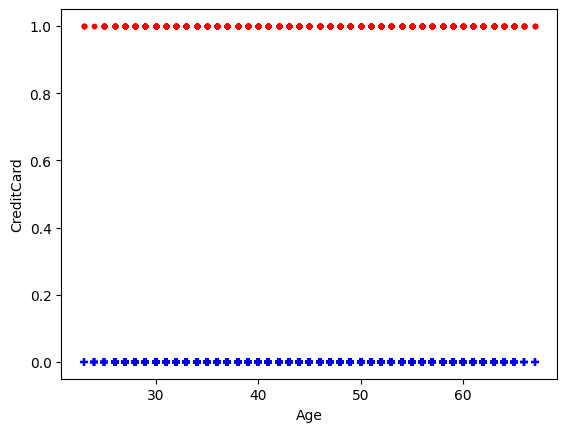

In [38]:
plt.xlabel("Age")
plt.ylabel("CreditCard")
plt.scatter(one_class["Age"], one_class["CreditCard"], color="blue", marker="+")
plt.scatter(zero_class["Age"], zero_class["CreditCard"], color="red", marker=".")

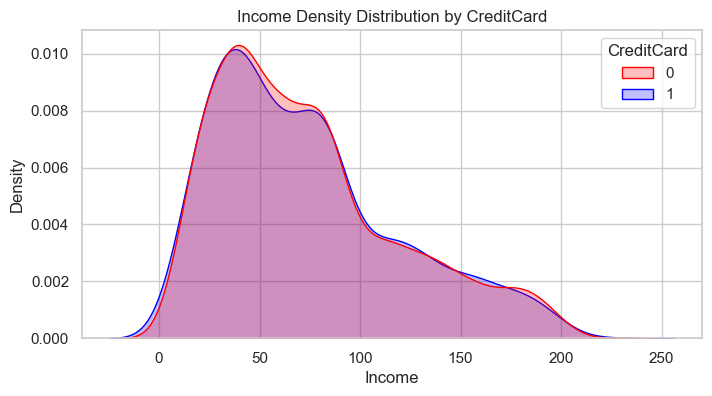

In [110]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=loc_df, x="Income", hue="CreditCard", common_norm=False, fill=True, palette=["red", "blue"])
plt.title("Income Density Distribution by CreditCard")
plt.show()

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_1092/2574073286.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loc_df, x="CreditCard", y="Income", palette=["red", "blue"])


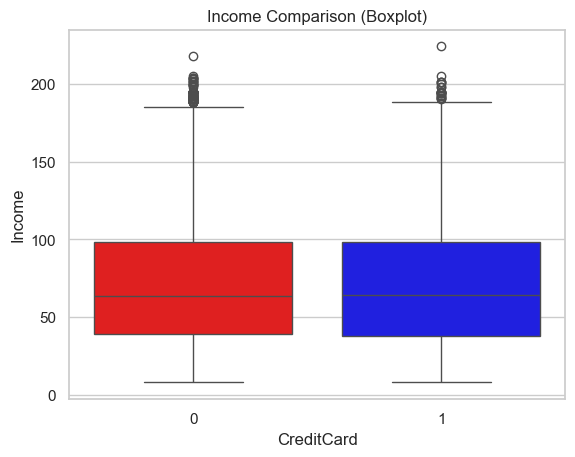

In [111]:
sns.boxplot(data=loc_df, x="CreditCard", y="Income", palette=["red", "blue"])
plt.title("Income Comparison (Boxplot)")
plt.show()

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_1092/2215844678.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=loc_df, x="CreditCard", y="Income", jitter=0.2, alpha=0.3, palette=["red", "blue"])


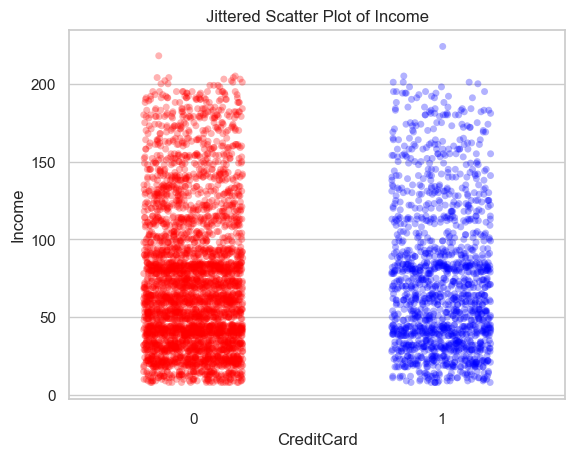

In [112]:
sns.stripplot(data=loc_df, x="CreditCard", y="Income", jitter=0.2, alpha=0.3, palette=["red", "blue"])
plt.title("Jittered Scatter Plot of Income")
plt.show()

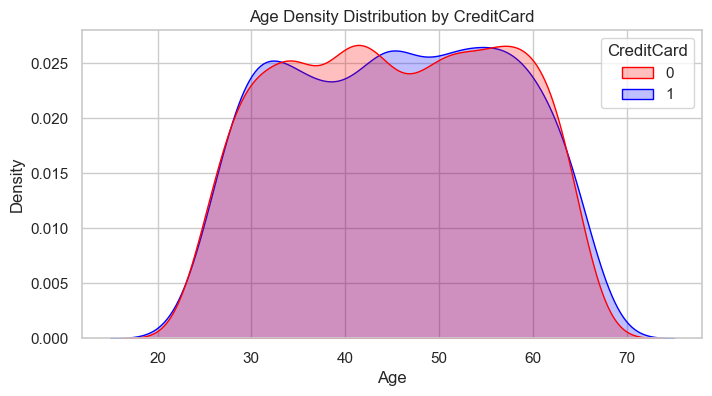

In [115]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=loc_df, x="Age", hue="CreditCard", common_norm=False, fill=True, palette=["red", "blue"])
plt.title("Age Density Distribution by CreditCard")
plt.show()

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_1092/2195614899.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=loc_df, x="CreditCard", y="Age", jitter=0.2, alpha=0.3, palette=["red", "blue"])


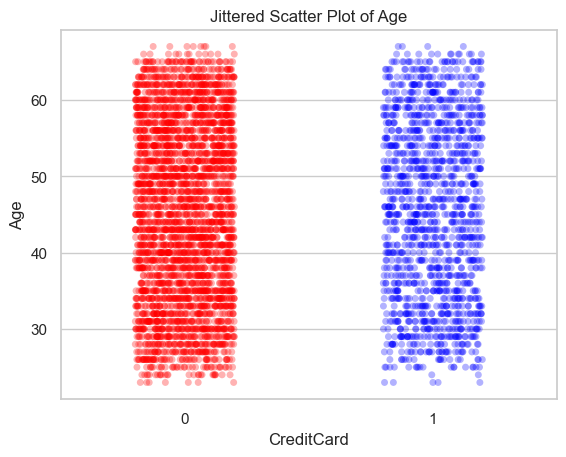

In [117]:
sns.stripplot(data=loc_df, x="CreditCard", y="Age", jitter=0.2, alpha=0.3, palette=["red", "blue"])
plt.title("Jittered Scatter Plot of Age")
plt.show()

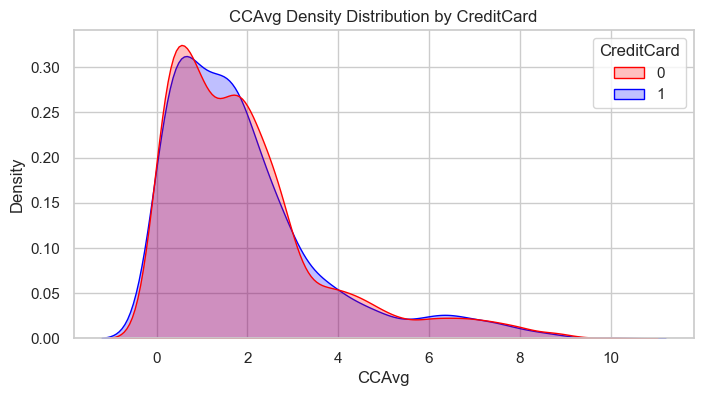

In [118]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=loc_df, x="CCAvg", hue="CreditCard", common_norm=False, fill=True, palette=["red", "blue"])
plt.title("CCAvg Density Distribution by CreditCard")
plt.show()

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_1092/133036866.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=loc_df, x="CreditCard", y="CCAvg", jitter=0.2, alpha=0.3, palette=["red", "blue"])


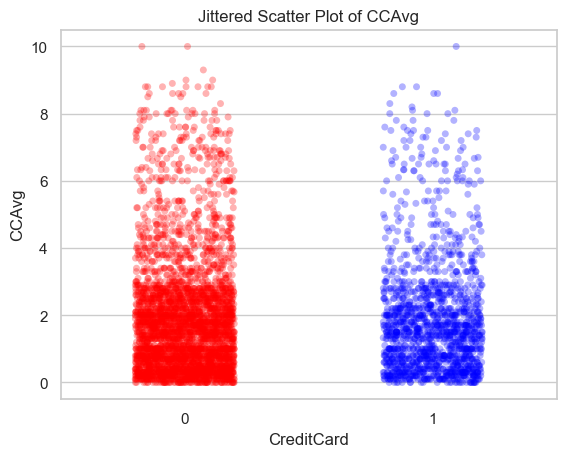

In [119]:
sns.stripplot(data=loc_df, x="CreditCard", y="CCAvg", jitter=0.2, alpha=0.3, palette=["red", "blue"])
plt.title("Jittered Scatter Plot of CCAvg")
plt.show()

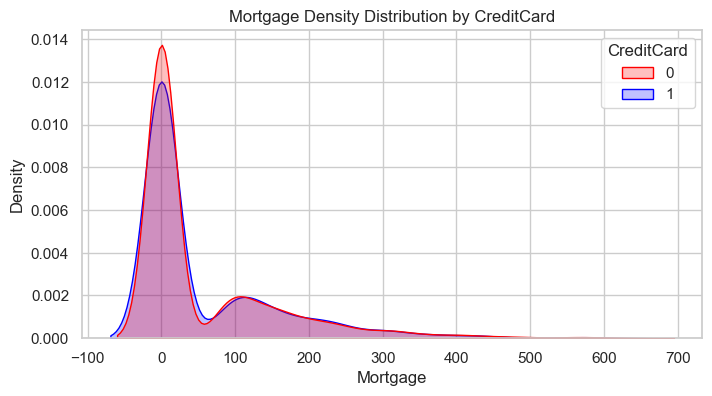

In [123]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=loc_df, x="Mortgage", hue="CreditCard", common_norm=False, fill=True, palette=["red", "blue"])
plt.title("Mortgage Density Distribution by CreditCard")
plt.show()

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_1092/2848587498.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=loc_df, x="CreditCard", y="Mortgage", jitter=0.2, alpha=0.3, palette=["red", "blue"])


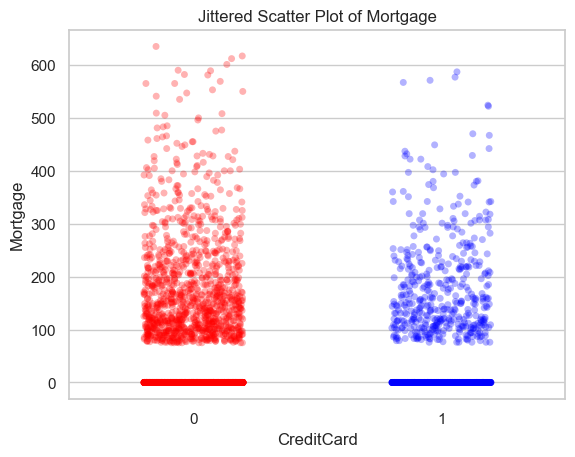

In [124]:
sns.stripplot(data=loc_df, x="CreditCard", y="Mortgage", jitter=0.2, alpha=0.3, palette=["red", "blue"])
plt.title("Jittered Scatter Plot of Mortgage")
plt.show()

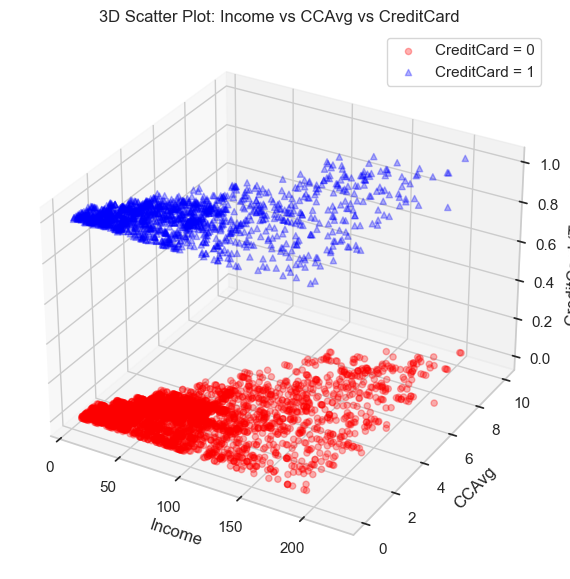

In [125]:
from mpl_toolkits.mplot3d import Axes3D

# Create canvas 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Sperate CreditCard = 0 and CreditCard = 1
g0 = loc_df[loc_df['CreditCard'] == 0]
g1 = loc_df[loc_df['CreditCard'] == 1]

ax.scatter(g0['Income'], g0['CCAvg'], g0['CreditCard'], c='red', marker='o', alpha=0.3, label='CreditCard = 0')
ax.scatter(g1['Income'], g1['CCAvg'], g1['CreditCard'], c='blue', marker='^', alpha=0.3, label='CreditCard = 1')

ax.set_xlabel('Income')
ax.set_ylabel('CCAvg')
ax.set_zlabel('CreditCard (Target)')
ax.set_title('3D Scatter Plot: Income vs CCAvg vs CreditCard')
ax.legend()

plt.show()

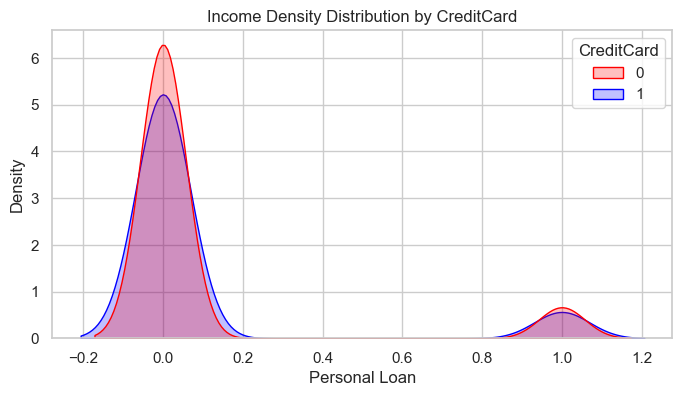

In [113]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=loc_df, x="Personal Loan", hue="CreditCard", common_norm=False, fill=True, palette=["red", "blue"])
plt.title("Income Density Distribution by CreditCard")
plt.show()

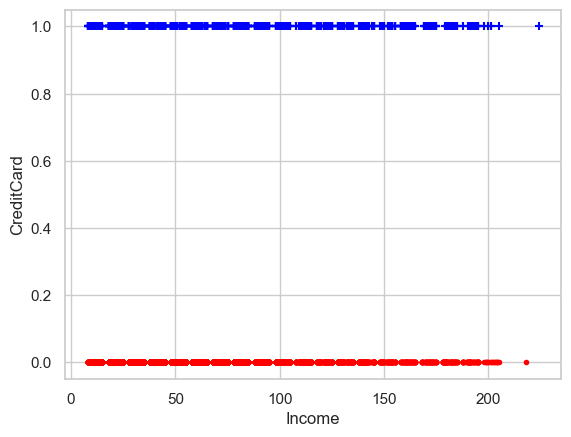

In [108]:
plt.xlabel("Income")
plt.ylabel("CreditCard")
plt.scatter(one_class["Income"], one_class["CreditCard"], color="red", marker=".")
plt.scatter(zero_class["Income"], zero_class["CreditCard"], color="blue", marker="+")

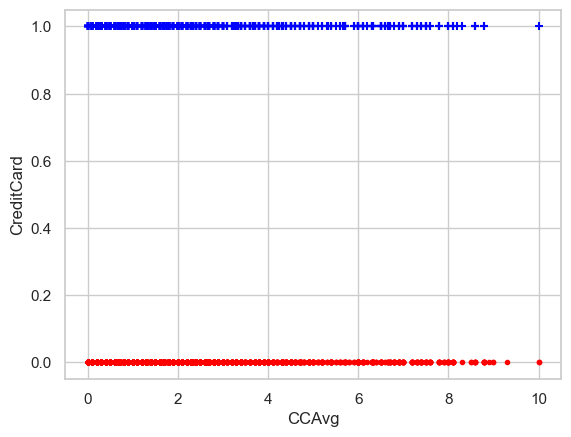

In [109]:
plt.xlabel("CCAvg")
plt.ylabel("CreditCard")
plt.scatter(one_class["CCAvg"], one_class["CreditCard"], color="red", marker=".")
plt.scatter(zero_class["CCAvg"], zero_class["CreditCard"], color="blue", marker="+")

### Scaling Data

In [29]:
def standard_scaler(X):

    mean = np.sum(X, axis=0) / X.shape[0]

    variance = np.sum((X - mean) ** 2, axis=0) / X.shape[0]
    std = np.sqrt(variance)

    std_scaler = (X - mean) / std

    return std_scaler

In [ ]:
scaled_df = standard_scaler(loc_df.drop("CreditCard", axis=1))
scaled_df

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online
0,-1.774417,-1.666078,-0.538229,1.397414,-0.193385,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618
1,-0.029524,-0.096330,-0.864109,0.525991,-0.250611,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618
2,-0.552992,-0.445163,-1.363793,-1.216855,-0.536736,-1.049078,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618
3,-0.901970,-0.968413,0.569765,-1.216855,0.436091,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618
4,-0.901970,-1.055621,-0.625130,1.397414,-0.536736,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618
...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.425438,-1.491662,-0.733757,-1.216855,-0.021710,1.332484,-0.555524,-0.325875,-0.341423,-0.25354,0.821951
4996,-1.338194,-1.404454,-1.276892,1.397414,-0.880087,-1.049078,0.280238,-0.325875,-0.341423,-0.25354,0.821951
4997,1.540880,1.647835,-1.081363,-0.345432,-0.937312,1.332484,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618
4998,1.715370,1.735043,-0.538229,0.525991,-0.822862,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,0.821951


In [ ]:
y = loc_df["CreditCard"]
y

0       0
1       0
2       0
3       0
4       1
       ..
4995    0
4996    0
4997    0
4998    0
4999    1
Name: CreditCard, Length: 5000, dtype: int64

### Implementation of SVM